 original data: [   1   10  100 1000]
 after log [0.         2.30258509 4.60517019 6.90775528]
 after log the new data [0.         1.60943791 2.30258509 3.91202301 4.60517019 6.2146081
 6.90775528]


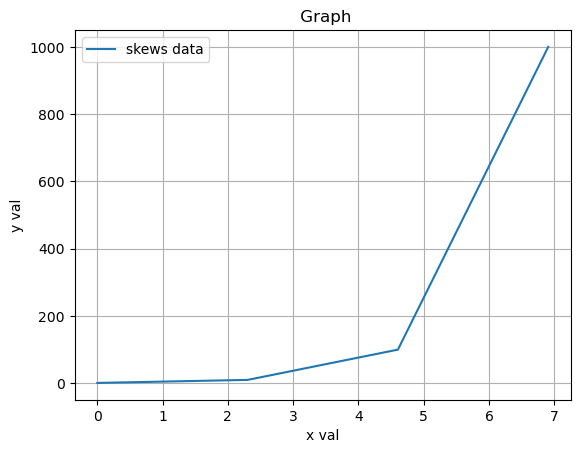

In [4]:
#natural logs
#related to skewness
import numpy as np
import matplotlib.pyplot as plt
data=np.array([1,10,100,1000])
log_data=np.log(data)
data_new=np.array([1,5,10,50,100,500,1000])
log_new=np.log(data_new)
print(" original data:",data)
print(" after log",log_data)
print(" after log the new data",log_new)
plt.plot(log_data,data,label="skews data")
plt.xlabel("x val")
plt.ylabel("y val")
plt.title(" Graph")
plt.legend()
plt.grid()
plt.show()

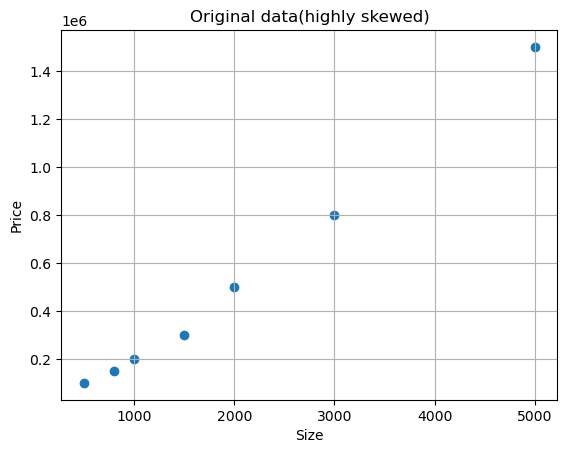

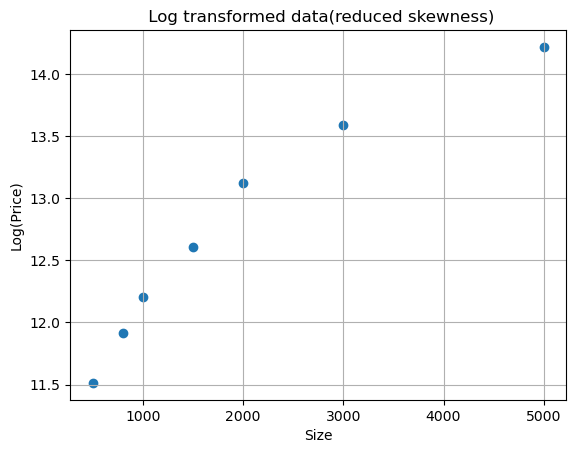

 MSE (original data):  1353958840.0885494
 MSE (log transformed data):  44271902675.910255


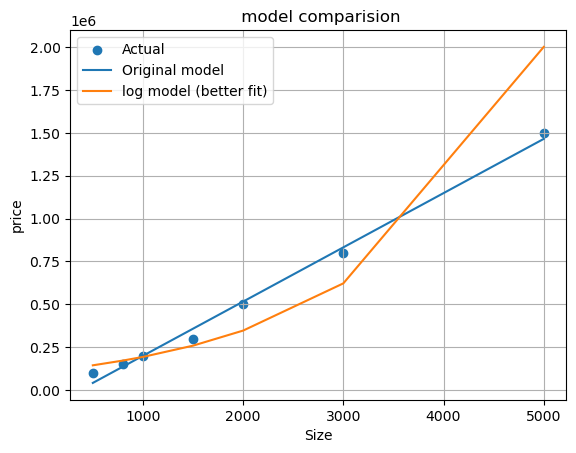

In [7]:
#house data and price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# create real world data set(house size vs price)
data={
    "Size":[500,800,1000,1500,2000,3000,5000],
    "Price": [100000,150000,200000,300000,500000,800000,1500000]
}
df = pd.DataFrame(data)

#visulize original data
plt.figure()
plt.scatter(df["Size"],df["Price"])
plt.title("Original data(highly skewed)")
plt.xlabel("Size")
plt.ylabel("Price")
plt.grid()
plt.show()

#apply natural log transformation
df["Log_Price"]=np.log(df["Price"])

#visualize transformed data
plt.figure()
plt.scatter(df["Size"],df["Log_Price"])
plt.title(" Log transformed data(reduced skewness)")
plt.xlabel("Size")
plt.ylabel("Log(Price)")
plt.grid()
plt.show()

#train model on original data
x=df[["Size"]]  # Convert to 2D array by using double brackets
y=df["Price"]
model_original=LinearRegression()
model_original.fit(x,y)
pred_original=model_original.predict(x)  # Fixed method call

#train model on log data
y_log=df["Log_Price"]

model_log=LinearRegression()
model_log.fit(x,y_log)  # x is already 2D
pred_log=model_log.predict(x)

#convert log prediction back
pred_log_exp=np.exp(pred_log)

#compare errors
mse_original=mean_squared_error(y,pred_original)  # Fixed variable name
mse_log=mean_squared_error(y,pred_log_exp)  # Added missing variable

print(" MSE (original data): ",mse_original)
print(" MSE (log transformed data): ",mse_log)

#plot comparission
plt.figure()
plt.scatter(df["Size"],y,label="Actual")
plt.plot(df["Size"],pred_original,label="Original model")
plt.plot(df["Size"],pred_log_exp,label="log model (better fit)")
plt.legend()
plt.title(" model comparision")
plt.xlabel("Size")
plt.ylabel("price")
plt.grid()
plt.show()

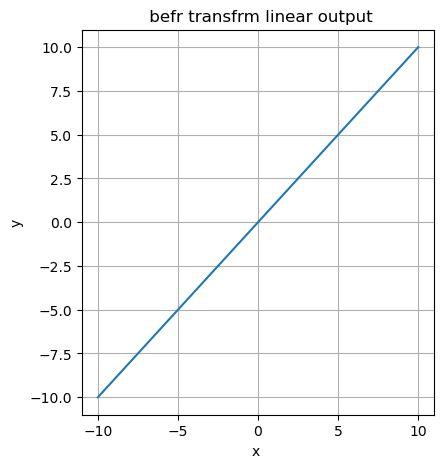

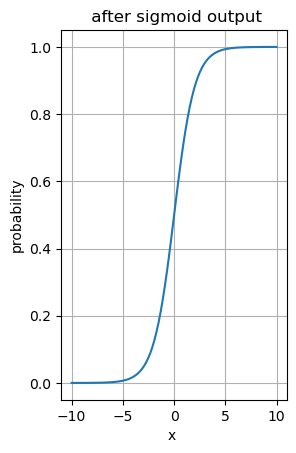

In [11]:
#sigmoid function for student data
x=np.linspace(-10,10,100)  #raw model output
#lineaer func before trnsform
y_linear=x
#define sigmoid function
y_sigmoid=1/(1+np.exp(-x))
#plot both graps
plt.figure(figsize=(10,5))
#before linear
plt.subplot(1,2,1)
plt.plot(x,y_linear)
plt.title(" befr transfrm linear output")
plt.xlabel("x ")
plt.ylabel("y")
plt.grid()
plt.show()
#after (sigmoid)
plt.subplot(1,2,2)
plt.plot(x,y_sigmoid)
plt.title(" after sigmoid output")
plt.xlabel("x ")
plt.ylabel("probability")
plt.grid()


Hours: 1, Raw: -2.80,probability: 0.057
Hours: 3, Raw: -0.40,probability: 0.401
Hours: 5, Raw: 2.00,probability: 0.881
Hours: 7, Raw: 4.40,probability: 0.988


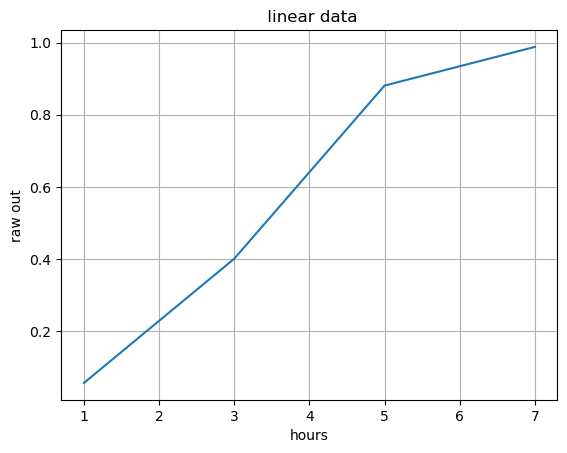

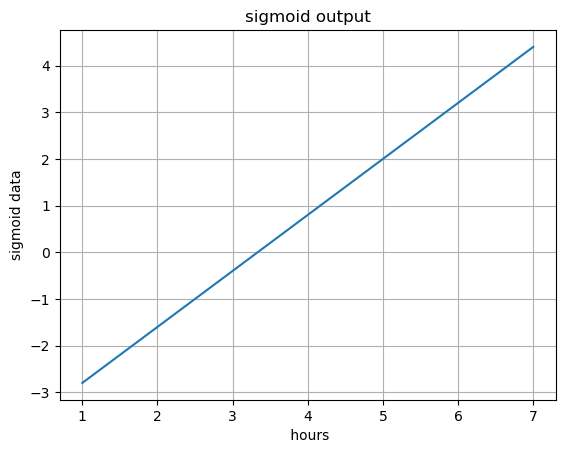

In [15]:
#students detail
#hours data
hours=np.array([1,3,5,7])
#linear model
z=1.2*hours-4
#sigmoid function
sigmoid=1/(1+np.exp(-z))
#output
for i in range(len(hours)):
    print(f"Hours: {hours[i]}, Raw: {z[i]:.2f},probability: {sigmoid[i]:.3f}")
plt.plot(hours,sigmoid,label="raw data")
plt.xlabel("hours")
plt.ylabel("raw out")
plt.title(" linear data")
plt.grid()
plt.show()
plt.plot(hours,z,label="sigmoid")
plt.xlabel(" hours")
plt.ylabel("sigmoid data")
plt.title("sigmoid output")
plt.grid()
plt.show()
#RELU
y=np.maximum(0,z)
plt.plot(hours,y)
plt.grid9